# HỆ THỐNG GỢI Ý PHÂN KHÚC KHÁCH HÀNG F&B & TOURISM TẠI TP.HCM

### 📌 Phiên bản v7 (gemini_v3) — 3 cải tiến thực nghiệm so với v6 (GEMINI_v2)

Pipeline weak labeling (Gemini), taxonomy, preprocessing, stratified split... **giữ nguyên** so với v6.

1. **Classifier thay thế cho SBERT/concat** — thêm Logistic Regression (LR) và Linear SVM song song với RF.
   LR/SVM khai thác tốt hơn không gian embedding dense so với RF (vốn thiết kế cho đặc trưng thưa).

2. **Giảm chiều TF-IDF bằng TruncatedSVD** — TF-IDF 5.000 → 300 chiều trước khi ghép với SBERT (768),
   tạo vector 1.068 chiều thay vì 5.768. Cân bằng tỷ lệ đóng góp giữa TF-IDF và SBERT.

3. **Baseline SBERT Multilingual song song** — `paraphrase-multilingual-mpnet-base-v2` trên cùng N=10.000
   với RF làm classifier. Biến thiên duy nhất là model embedding, tách bạch nguyên nhân sụt giảm F1.

| Nhánh | Embedding | Classifier |
|---|---|---|
| TF-IDF + RF | TF-IDF (5k) | RF |
| SBERT-VN + RF | vi-bi-encoder (768) | RF |
| SBERT-VN + LR | vi-bi-encoder (768) | LR |
| SBERT-VN + SVM | vi-bi-encoder (768) | LinearSVC |
| SVD-TF-IDF+SBERT-VN + RF | SVD(300)+SBERT (1068) | RF |
| SVD-TF-IDF+SBERT-VN + LR | SVD(300)+SBERT (1068) | LR |
| SBERT-ML + RF | mpnet-multilingual (768) | RF |

⚠️ Notebook này dùng lại **checkpoint** Gemini (`gemini_weak_label_checkpoint.csv`) từ v6 nếu đã có.


In [1]:
!pip install -q datasets transformers scikit-learn torch sentence-transformers pandas numpy matplotlib seaborn scipy iterative-stratification



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\DUNG\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, precision_score, recall_score, cohen_kappa_score
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from scipy.stats import wilcoxon

# Multi-label stratified split/CV
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit, MultilabelStratifiedKFold

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DEVICE = 0 if torch.cuda.is_available() else -1
device_name = 'GPU' if DEVICE == 0 else 'CPU'
print(f"Import thanh cong | Thiet bi: {device_name}")


Import thanh cong | Thiet bi: CPU


## 1. Load & Lọc Dataset (TP.HCM)

In [3]:
dataset = load_dataset("nvidia/Nemotron-Personas-Vietnam", split="train")
df = dataset.to_pandas()

df_hcm = df[df['region'] == 'Thành Phố Hồ Chí Minh'].copy()
df_hcm = df_hcm.reset_index(drop=True)

print(f"So records TP.HCM: {len(df_hcm):,}")


So records TP.HCM: 34,733


## 2. Lấy mẫu N=10.000 (giống v6)

In [4]:
SAMPLE_SIZE = 10000

if len(df_hcm) > SAMPLE_SIZE:
    df_sample = df_hcm.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)
else:
    df_sample = df_hcm.reset_index(drop=True)

print(f"Kich thuoc tap thuc nghiem: {len(df_sample):,} persona")


Kich thuoc tap thuc nghiem: 10,000 persona


## 3. Hợp nhất Văn bản Persona

In [5]:
def merge_text(row):
    fields = ['persona', 'professional_persona', 'culinary_persona', 'travel_persona',
              'hobbies_and_interests', 'cultural_background']
    parts = [str(row.get(f, '')) for f in fields if pd.notna(row.get(f)) and str(row.get(f)).strip()]
    return ' '.join(parts)

df_sample['merged_text'] = df_sample.apply(merge_text, axis=1)
print('Da hop nhat van ban')
print(f"Do dai trung binh: {df_sample['merged_text'].str.len().mean():.0f} ky tu")


Da hop nhat van ban
Do dai trung binh: 1273 ky tu


## 4. Taxonomy Ngành hàng F&B & Tourism

In [6]:
taxonomy = {
    'fnb_street':     'thích ăn uống vỉa hè bình dân, món ăn đường phố giá rẻ',
    'fnb_fine':        'thích nhà hàng sang trọng, ẩm thực cao cấp, trải nghiệm fine-dining đắt tiền',
    'fnb_cafe':        'thích ngồi quán cà phê, không gian yên tĩnh để làm việc hoặc trò chuyện',
    'fnb_healthy':     'quan tâm ăn uống lành mạnh, ăn chay, thực phẩm hữu cơ, giữ vóc dáng',
    'tour_cultural':   'thích tham quan di tích lịch sử, đền chùa, bảo tàng, giá trị văn hóa truyền thống',
    'tour_resort':     'thích nghỉ dưỡng cao cấp, resort biển, spa thư giãn, du lịch sang trọng',
    'tour_adventure':  'thích phượt, leo núi, khám phá thiên nhiên hoang dã, du lịch mạo hiểm',
    'tour_food':       'thích đi du lịch chỉ để khám phá và thưởng thức món ăn đặc sản địa phương',
    'tour_festival':   'thích tham gia lễ hội, sự kiện âm nhạc, hoạt động cộng đồng đông người',
}

labels = list(taxonomy.keys())
candidate_label_texts = list(taxonomy.values())

print('Taxonomy gom', len(labels), 'phan khuc (v5: candidate label da co dau day du)')


Taxonomy gom 9 phan khuc (v5: candidate label da co dau day du)


## 5. Weak Labeling bằng Gemini (tái sử dụng checkpoint v6 nếu có)

**Lưu ý:** Notebook này **tái sử dụng `gemini_weak_label_checkpoint.csv`** từ v6 nếu file đã tồn tại.
Chỉ gọi lại API nếu chưa có checkpoint hoặc checkpoint bị thiếu.

Nếu cần chạy lại từ đầu, xóa file `gemini_weak_label_checkpoint.csv` trước khi chạy cell này.

In [7]:
!pip install -q google-genai pydantic



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\DUNG\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
import time
import json as _json
import random
import datetime

from google import genai
from google.genai import types
from pydantic import BaseModel, Field

# ================== CAU HINH ==================
GEMINI_MODEL = "gemini-3.5-flash-lite"

GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY", "")

client = genai.Client(api_key=GEMINI_API_KEY)

BATCH_SIZE = 50
MAX_CHARS_PER_PERSONA = 400

FREE_TIER_RPM = 10  
SLEEP_BETWEEN_CALLS = round(max(8.0, 60.0 / FREE_TIER_RPM + 1.0), 1)

MAX_RETRIES = 6
BASE_BACKOFF = 6.0

CHECKPOINT_PATH = "gemini_weak_label_checkpoint.csv"

n_batches_preview = -(-SAMPLE_SIZE // BATCH_SIZE)
print(f"Model: {GEMINI_MODEL}")
print(f"Thoi diem chay: {datetime.datetime.now().isoformat()}")
print(f"FREE_TIER_RPM da khai bao: {FREE_TIER_RPM} -> sleep giua cac batch: {SLEEP_BETWEEN_CALLS}s")
print(f"Batch size: {BATCH_SIZE} persona/request")
print(f"[LUU Y] Neu SAMPLE_SIZE={SAMPLE_SIZE} persona -> ~{n_batches_preview} batch tong cong.")


Model: gemini-3.5-flash-lite
Thoi diem chay: 2026-08-17T13:50:43.678021
FREE_TIER_RPM da khai bao: 10 -> sleep giua cac batch: 8.0s
Batch size: 50 persona/request
[LUU Y] Neu SAMPLE_SIZE=10000 persona -> ~200 batch tong cong.


In [9]:
# ================== SCHEMA JSON ==================
class PersonaLabel(BaseModel):
    persona_id: int
    fnb_street: float = Field(ge=0, le=1)
    fnb_fine: float = Field(ge=0, le=1)
    fnb_cafe: float = Field(ge=0, le=1)
    fnb_healthy: float = Field(ge=0, le=1)
    tour_cultural: float = Field(ge=0, le=1)
    tour_resort: float = Field(ge=0, le=1)
    tour_adventure: float = Field(ge=0, le=1)
    tour_food: float = Field(ge=0, le=1)
    tour_festival: float = Field(ge=0, le=1)

class BatchLabelResponse(BaseModel):
    results: list[PersonaLabel]

_score_fields = [f for f in PersonaLabel.model_fields.keys() if f != "persona_id"]
assert _score_fields == labels

GEMINI_SYSTEM_PROMPT = (
    "Bạn là annotator chuyên môn. Đọc mô tả persona tiếng Việt và chấm điểm từ 0.00 đến 1.00 cho MỖI tiêu chí "
    "theo mức độ phù hợp giữa persona và tiêu chí đó.\n\n"
    "THANG ĐIỂM:\n"
    "  0.00-0.15: không có bằng chứng.\n"
    "  0.15-0.40: gợi ý yếu, gián tiếp.\n"
    "  0.40-0.65: có nhắc đến nhưng không phải ưu tiên chính.\n"
    "  0.65-0.85: rõ ràng là sở thích/thói quen.\n"
    "  0.85-1.00: nổi bật, được nhấn mạnh nhiều lần hoặc nằm ở trọng tâm.\n\n"
    "QUY TẮc:\n"
    "  - Mỗi tiêu chí chấm độc lập; điểm của tiêu chí này không ảnh hưởng đến tiêu chí khác.\n"
    "  - Một persona có thể phù hợp với nhiều tiêu chí hoặc không phù hợp với tiêu chí nào.\n"
    "  - Chỉ dựa trên văn bản được cung cấp; KHÔNG suy diễn từ tuổi, giới tính, nghề nghiệp, nơi sống hoặc khuôn mẫu.\n"
    "  - Nếu không chắc chắn, chọn mức thấp hơn nhưng vẫn dựa trên bằng chứng trong văn bản.\n\n"
    "TIÊU CHÍ:\n"
    + "\n".join(f"- {k}: {v}" for k, v in taxonomy.items())
)

print("Da dinh nghia schema va prompt he thong cho Gemini weak labeling.")


Da dinh nghia schema va prompt he thong cho Gemini weak labeling.


In [10]:
def _build_batch_prompt(batch_texts, batch_ids, max_chars):
    items_str = "\n\n".join(
        f'[persona_id={pid}]\n\"\"\"\n{t[:max_chars]}\n\"\"\"'
        for pid, t in zip(batch_ids, batch_texts)
    )
    return (
        f"{GEMINI_SYSTEM_PROMPT}\n\n"
        f"Co {len(batch_ids)} persona. Voi MOI persona, tra ve diem cho 9 tieu chi theo dung schema JSON.\n"
        f"Bat buoc: `results` phai chua dung {len(batch_ids)} phan tu; moi phan tu phai co `persona_id` khop dung mot ID trong {sorted(batch_ids)}; khong bo sot, khong them ID khac, khong gop nhieu persona thanh 1.\n\n"
        f"{items_str}"
    )


def call_gemini_batch_once(batch_texts, batch_ids, max_chars=MAX_CHARS_PER_PERSONA):
    prompt = _build_batch_prompt(batch_texts, batch_ids, max_chars)
    valid_ids = set(batch_ids)

    for attempt in range(MAX_RETRIES):
        try:
            response = client.models.generate_content(
                model=GEMINI_MODEL,
                contents=prompt,
                config=types.GenerateContentConfig(
                    response_mime_type="application/json",
                    response_schema=BatchLabelResponse,
                    temperature=0.0,
                ),
            )
            parsed = response.parsed
            if parsed is None:
                parsed = BatchLabelResponse(**_json.loads(response.text))

            result_map = {}
            for item in parsed.results:
                if item.persona_id in valid_ids and item.persona_id not in result_map:
                    result_map[item.persona_id] = [getattr(item, lb) for lb in labels]
            return result_map

        except Exception as e:
            err_str = str(e)
            is_rate_limit = ("429" in err_str) or ("RESOURCE_EXHAUSTED" in err_str) or ("rate" in err_str.lower())
            is_last_attempt = (attempt == MAX_RETRIES - 1)

            if is_last_attempt:
                print(f"\n[LOI - HET RETRY O BATCH NAY] {err_str[:200]}")
                return {}

            backoff = BASE_BACKOFF * (2 ** attempt) + random.uniform(0, 1.5)
            tag = "RATE LIMIT/TPM" if is_rate_limit else "LOI TAM THOI"
            print(f"\n[{tag}] Cho {backoff:.1f}s roi thu lai batch (lan {attempt + 1}/{MAX_RETRIES})...", end="")
            time.sleep(backoff)

    return {}


def call_gemini_batch_recursive(batch_texts, batch_ids, depth=0, max_depth=8):
    result_map = call_gemini_batch_once(batch_texts, batch_ids)

    missing_pairs = [(pid, t) for pid, t in zip(batch_ids, batch_texts) if pid not in result_map]
    if not missing_pairs:
        return result_map

    if len(batch_ids) == 1 or depth >= max_depth:
        for pid, _ in missing_pairs:
            print(f"\n[LOI - BO QUA] persona_id={pid} khong the gan nhan sau nhieu lan thu/chia nho.")
        return result_map

    missing_ids = [p[0] for p in missing_pairs]
    missing_texts = [p[1] for p in missing_pairs]
    mid = max(1, len(missing_ids) // 2)

    print(f"\n[THIEU {len(missing_ids)}/{len(batch_ids)} ID o batch nay] Chia doi va thu lai...")
    sub1 = call_gemini_batch_recursive(missing_texts[:mid], missing_ids[:mid], depth + 1, max_depth)
    sub2 = call_gemini_batch_recursive(missing_texts[mid:], missing_ids[mid:], depth + 1, max_depth)

    result_map.update(sub1)
    result_map.update(sub2)
    return result_map


def gemini_weak_label_batched(texts, batch_size=BATCH_SIZE, resume=True):
    n = len(texts)
    all_scores = np.full((n, len(labels)), np.nan)
    score_cols = [f"{lb}_score_gemini" for lb in labels]

    start_idx = 0
    if resume and os.path.exists(CHECKPOINT_PATH):
        ckpt = pd.read_csv(CHECKPOINT_PATH)
        done = len(ckpt)
        if done > 0:
            all_scores[:done] = ckpt[score_cols].values
            start_idx = (done // batch_size) * batch_size
            print(f"[RESUME] Tim thay checkpoint: {done}/{n} persona -> tiep tuc tu index {start_idx}")

    idx = start_idx
    n_batches_total = (n + batch_size - 1) // batch_size
    while idx < n:
        end = min(idx + batch_size, n)
        batch_texts = texts[idx:end]
        batch_local_ids = list(range(end - idx))

        result_map = call_gemini_batch_recursive(batch_texts, batch_local_ids)
        for local_id, scores in result_map.items():
            all_scores[idx + local_id] = scores

        idx = end
        cur_batch_no = idx // batch_size + (1 if idx % batch_size else 0)
        print(f"  Da xu ly {idx}/{n} persona (~batch {cur_batch_no}/{n_batches_total})...", end="\r")

        ckpt_df = pd.DataFrame(all_scores[:idx], columns=score_cols)
        ckpt_df.to_csv(CHECKPOINT_PATH, index=False)

        if idx < n:
            time.sleep(SLEEP_BETWEEN_CALLS)

    return all_scores

print("Da dinh nghia ham gan nhan theo BATCH (co tu chia nho khi loi + checkpoint/resume).")


Da dinh nghia ham gan nhan theo BATCH (co tu chia nho khi loi + checkpoint/resume).


In [11]:
n_persona = len(df_sample)
n_batches = (n_persona + BATCH_SIZE - 1) // BATCH_SIZE
est_seconds = n_batches * (SLEEP_BETWEEN_CALLS + 4.0)
print(f"So persona can gan nhan: {n_persona} | So batch (moi batch {BATCH_SIZE} persona): {n_batches}")
print(f"Uoc luong thoi gian chay (khong tinh retry/chia nho): ~{est_seconds/60:.1f} phut")
print("Bat dau weak labeling theo batch bang Gemini 3.5 Flash-Lite...\n")

y_scores_gemini = gemini_weak_label_batched(df_sample['merged_text'].tolist())

failed_mask = np.isnan(y_scores_gemini).any(axis=1)
n_failed = int(failed_mask.sum())
if n_failed > 0:
    print(f"\n[CANH BAO] {n_failed}/{n_persona} persona bi loi khi goi Gemini (het retry/chia nho).")
    df_sample = df_sample.loc[~failed_mask].reset_index(drop=True)
    y_scores_gemini = y_scores_gemini[~failed_mask]
else:
    print("\nKhong co persona nao bi loi.")


So persona can gan nhan: 10000 | So batch (moi batch 50 persona): 200
Uoc luong thoi gian chay (khong tinh retry/chia nho): ~40.0 phut
Bat dau weak labeling theo batch bang Gemini 3.5 Flash-Lite...

  Da xu ly 10000/10000 persona (~batch 200/200)...
Khong co persona nao bi loi.


In [12]:
def compute_adaptive_thresholds(scores, target_rate=0.25):
    n_labels = scores.shape[1]
    thresholds = np.zeros(n_labels)
    for j in range(n_labels):
        thresholds[j] = np.percentile(scores[:, j], 100 * (1 - target_rate))
    return thresholds


def binarize_labels_adaptive(scores, thresholds, max_labels=3):
    binary = np.zeros_like(scores, dtype=int)
    for i in range(len(scores)):
        candidates = np.where(scores[i] >= thresholds)[0]
        if len(candidates) == 0:
            candidates = np.array([np.argmax(scores[i])])
        if len(candidates) > max_labels:
            top = candidates[np.argsort(scores[i][candidates])[::-1][:max_labels]]
            binary[i, top] = 1
        else:
            binary[i, candidates] = 1
    return binary

TARGET_POSITIVE_RATE = 0.25
MAX_LABELS = 3
adaptive_thresholds = compute_adaptive_thresholds(y_scores_gemini, target_rate=TARGET_POSITIVE_RATE)
y_binary = binarize_labels_adaptive(y_scores_gemini, adaptive_thresholds, max_labels=MAX_LABELS)

for i, label in enumerate(labels):
    df_sample[label] = y_binary[:, i]
    df_sample[f"{label}_score"] = y_scores_gemini[:, i]

print(f"\nWeak labeling (Gemini 3.5 Flash-Lite, batch={BATCH_SIZE}) hoan tat | So nhan trung binh/persona: {y_binary.sum(axis=1).mean():.2f}")
print(f"Kich thuoc tap sau khi loai persona loi: {len(df_sample)}")



Weak labeling (Gemini 3.5 Flash-Lite, batch=50) hoan tat | So nhan trung binh/persona: 2.23
Kich thuoc tap sau khi loai persona loi: 10000


## 6. QC Nhãn yếu

In [13]:
qc_sample = df_sample.sample(n=min(15, len(df_sample)), random_state=RANDOM_STATE)
print("=== MAU KIEM TRA THU CONG (QC) ===")
for idx, row in qc_sample.iterrows():
    assigned = [l for l in labels if row[l] == 1]
    print(f"\n--- Persona #{idx} ---")
    print("Van ban (rut gon):", row['merged_text'][:200], "...")
    print("Nhan duoc gan:", assigned if assigned else "(khong nhan nao vuot nguong)")


=== MAU KIEM TRA THU CONG (QC) ===

--- Persona #6252 ---
Van ban (rut gon): Nguyễn Thị Lan, 26 tuổi, đang sống trong một căn hộ tập thể tại khu Phường 8, Bình Thạnh. Cô là một phụ nữ trẻ với sự tò mò về nghệ thuật và truyền thống, luôn tìm cách kết nối với cộng đồng qua các h ...
Nhan duoc gan: ['tour_cultural', 'tour_festival']

--- Persona #4684 ---
Van ban (rut gon): Lê Đức Tuấn, một chàng trai 29 tuổi làm trong ngành y tế tại Sài Gòn. Anh có niềm đam mê nghệ thuật và thích khám phá các món ăn mới. Anh cũng là người năng động, yêu thể thao và thích tham gia các lễ ...
Nhan duoc gan: ['tour_cultural', 'tour_adventure', 'tour_festival']

--- Persona #1731 ---
Van ban (rut gon): Anh Lê Quốc Hải là một người đàn ông trưởng thành, 39 tuổi, sinh ra và lớn lên trong một căn nhà tập thể ở Sài Gòn. Anh yêu thích sự cân bằng giữa truyền thống và hiện đại, đặc biệt là trong việc kết  ...
Nhan duoc gan: ['tour_cultural']

--- Persona #4742 ---
Van ban (rut gon): Anh Nguyễn Đức Tuấn, 22 tuổi, m

## 7. Thống kê & EDA

Phan phoi nhan yeu:
  fnb_street: 4619 (46.2%)
  tour_adventure: 3595 (36.0%)
  tour_food: 2632 (26.3%)
  tour_festival: 2593 (25.9%)
  tour_cultural: 2483 (24.8%)
  tour_resort: 2158 (21.6%)
  fnb_healthy: 1700 (17.0%)
  fnb_cafe: 1518 (15.2%)
  fnb_fine: 1043 (10.4%)


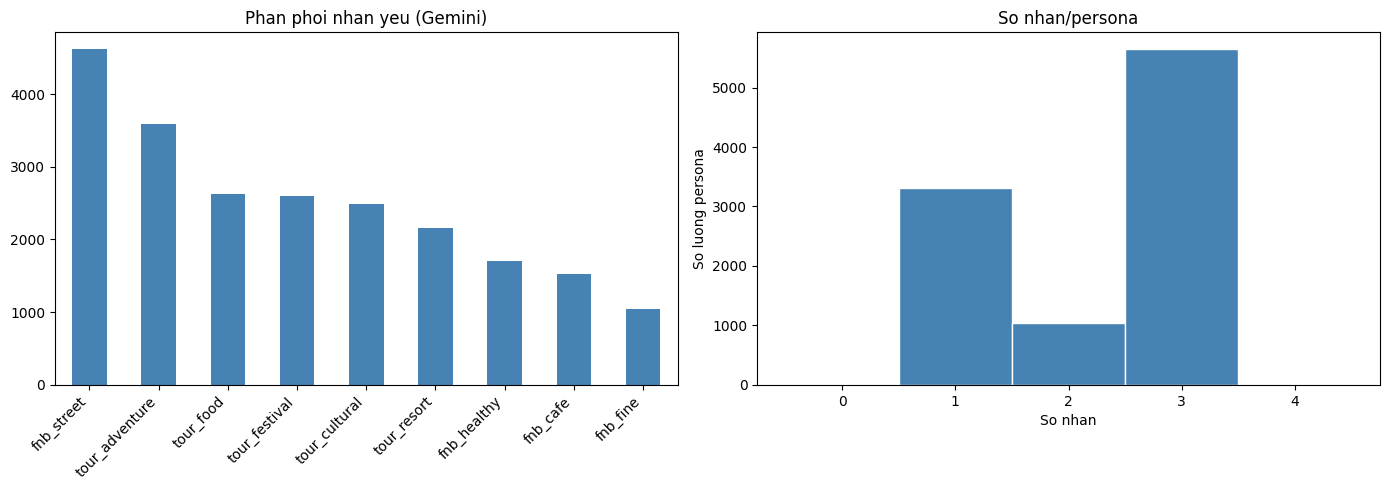

Da luu eda_summary_v7.png


In [14]:
label_counts = {lb: int(df_sample[lb].sum()) for lb in labels}
print("Phan phoi nhan yeu:")
for lb, cnt in sorted(label_counts.items(), key=lambda x: -x[1]):
    print(f"  {lb}: {cnt} ({100*cnt/len(df_sample):.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pd.Series(label_counts).sort_values(ascending=False).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Phan phoi nhan yeu (Gemini)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

label_per_persona = y_binary.sum(axis=1)
axes[1].hist(label_per_persona, bins=range(0, MAX_LABELS+3), align='left', color='steelblue', edgecolor='white')
axes[1].set_title('So nhan/persona')
axes[1].set_xlabel('So nhan')
axes[1].set_ylabel('So luong persona')
plt.tight_layout()
plt.savefig('eda_summary_v7.png', dpi=120)
plt.show()
print("Da luu eda_summary_v7.png")


## 8. Trích xuất Đặc trưng — TF-IDF, SBERT-VN, SVD-concat, SBERT-ML

### CẢI TIẾN v7 (2): TruncatedSVD để cân bằng TF-IDF vs SBERT
Giảm chiều TF-IDF 5.000 → 300 bằng TruncatedSVD trước khi concat với SBERT (768),
tạo vector 1.068 chiều thay vì 5.768 chiều.

### CẢI TIẾN v7 (3): Baseline SBERT Multilingual song song
Chạy `paraphrase-multilingual-mpnet-base-v2` trên cùng N=10.000 với RF.
Biến thiên duy nhất là model embedding, không đổi classifier.

In [15]:
texts = df_sample['merged_text'].tolist()

# --- TF-IDF (5.000 chieu) ---
print("Dang tinh TF-IDF...")
tfidf_vec = TfidfVectorizer(max_features=5000, sublinear_tf=True)
X_tfidf = tfidf_vec.fit_transform(texts)
print(f"TF-IDF shape: {X_tfidf.shape}")

# --- TruncatedSVD: TF-IDF 5000 -> 300 ---
print("Dang giam chieu TF-IDF bang TruncatedSVD (5000 -> 300)...")
SVD_N_COMPONENTS = 300
svd = TruncatedSVD(n_components=SVD_N_COMPONENTS, random_state=RANDOM_STATE)
normalizer = Normalizer(copy=False)
X_tfidf_svd = normalizer.fit_transform(svd.fit_transform(X_tfidf))  # (n, 300)
explained_var = svd.explained_variance_ratio_.sum()
print(f"SVD-TF-IDF shape: {X_tfidf_svd.shape} | Phuong sai giai thich: {explained_var:.3f}")

# --- SBERT-VN: bkai vietnamese-bi-encoder ---
print("\nDang encode SBERT tieng Viet (bkai-foundation-models/vietnamese-bi-encoder)...")
sbert_vn = SentenceTransformer('bkai-foundation-models/vietnamese-bi-encoder')
X_sbert_vn = sbert_vn.encode(texts, batch_size=64, show_progress_bar=True, convert_to_numpy=True)
print(f"SBERT-VN shape: {X_sbert_vn.shape}")

# --- SVD-TF-IDF + SBERT-VN (concat, 300+768=1068 chieu) ---
print("\nDang noi SVD-TF-IDF + SBERT-VN...")
X_svd_concat = np.hstack([X_tfidf_svd, X_sbert_vn])  # (n, 1068)
print(f"SVD-TF-IDF+SBERT-VN shape: {X_svd_concat.shape}")

# --- SBERT-ML: paraphrase-multilingual-mpnet-base-v2 ---
print("\nDang encode SBERT Multilingual (paraphrase-multilingual-mpnet-base-v2)...")
sbert_ml = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')
X_sbert_ml = sbert_ml.encode(texts, batch_size=64, show_progress_bar=True, convert_to_numpy=True)
print(f"SBERT-ML shape: {X_sbert_ml.shape}")

print("\n=== Tom tat cac dac trung ===")
print(f"TF-IDF (sparse):         {X_tfidf.shape}")
print(f"SVD-TF-IDF (dense):      {X_tfidf_svd.shape}")
print(f"SBERT-VN (dense):        {X_sbert_vn.shape}")
print(f"SVD-TF-IDF+SBERT-VN:     {X_svd_concat.shape}")
print(f"SBERT-ML (dense):        {X_sbert_ml.shape}")


Dang tinh TF-IDF...
TF-IDF shape: (10000, 4679)
Dang giam chieu TF-IDF bang TruncatedSVD (5000 -> 300)...
SVD-TF-IDF shape: (10000, 300) | Phuong sai giai thich: 0.620

Dang encode SBERT tieng Viet (bkai-foundation-models/vietnamese-bi-encoder)...


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

SBERT-VN shape: (10000, 768)

Dang noi SVD-TF-IDF + SBERT-VN...
SVD-TF-IDF+SBERT-VN shape: (10000, 1068)

Dang encode SBERT Multilingual (paraphrase-multilingual-mpnet-base-v2)...


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

SBERT-ML shape: (10000, 768)

=== Tom tat cac dac trung ===
TF-IDF (sparse):         (10000, 4679)
SVD-TF-IDF (dense):      (10000, 300)
SBERT-VN (dense):        (10000, 768)
SVD-TF-IDF+SBERT-VN:     (10000, 1068)
SBERT-ML (dense):        (10000, 768)


## 9. Multilabel Stratified Split (Train/Test Holdout)

In [16]:
y = y_binary.copy()
n_total = len(y)

msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
idx_train, idx_test = next(msss.split(np.zeros(n_total), y))

y_train, y_test = y[idx_train], y[idx_test]

X_tfidf_train  = X_tfidf[idx_train]
X_tfidf_test   = X_tfidf[idx_test]

X_svd_train    = X_tfidf_svd[idx_train]
X_svd_test     = X_tfidf_svd[idx_test]

X_sbert_vn_train = X_sbert_vn[idx_train]
X_sbert_vn_test  = X_sbert_vn[idx_test]

X_svd_concat_train = X_svd_concat[idx_train]
X_svd_concat_test  = X_svd_concat[idx_test]

X_sbert_ml_train = X_sbert_ml[idx_train]
X_sbert_ml_test  = X_sbert_ml[idx_test]

print(f"Train: {len(idx_train):,} | Test: {len(idx_test):,}")
print(f"Trung binh nhan/persona (train): {y_train.sum(axis=1).mean():.2f}")
print(f"Trung binh nhan/persona (test):  {y_test.sum(axis=1).mean():.2f}")


Train: 8,020 | Test: 1,980
Trung binh nhan/persona (train): 2.23
Trung binh nhan/persona (test):  2.26


## 10. Hàm Trợ giúp — Train/Predict với Tuned Threshold

### CẢI TIẾN v7 (1): Hỗ trợ nhiều loại classifier

`make_classifier(clf_type)` tạo `MultiOutputClassifier` với RF / LR / SVM.
`fit_predict_with_tuned_thresholds` chấp nhận tham số `clf_type`.

In [17]:
# --- Majority Baseline ---
def majority_baseline_predict(y_tr, n_test):
    rates = y_tr.mean(axis=0)
    preds = (np.tile(rates, (n_test, 1)) >= 0.5).astype(int)
    for i in range(n_test):
        if preds[i].sum() == 0:
            preds[i, np.argmax(rates)] = 1
    return preds, rates, None


# --- Precision / Recall @K ---
def precision_recall_at_k(y_true, y_score, k=3):
    n = len(y_true)
    prec, rec = [], []
    for i in range(n):
        top_k = np.argsort(y_score[i])[::-1][:k]
        rel = y_true[i][top_k].sum()
        prec.append(rel / k)
        total_pos = y_true[i].sum()
        rec.append(rel / total_pos if total_pos > 0 else 0.0)
    return np.mean(prec), np.mean(rec)


# --- Tao classifier theo loai ---
def make_classifier(clf_type, random_state=RANDOM_STATE):
    """clf_type: 'RF' | 'LR' | 'SVM'"""
    if clf_type == 'RF':
        base = RandomForestClassifier(
            n_estimators=200, class_weight='balanced',
            random_state=random_state, n_jobs=-1
        )
    elif clf_type == 'LR':
        base = LogisticRegression(
            C=1.0, solver='saga', max_iter=2000,
            class_weight='balanced', random_state=random_state,
            n_jobs=-1
        )
    elif clf_type == 'SVM':
        base = LinearSVC(
            C=1.0, class_weight='balanced',
            max_iter=2000, random_state=random_state
        )
    else:
        raise ValueError(f"clf_type khong hop le: {clf_type}")
    return MultiOutputClassifier(base, n_jobs=1)


# --- Train + predict voi tuned threshold ---
def fit_predict_with_tuned_thresholds(X_tr, y_tr, X_te, clf_type='RF', target_rate=0.25):
    """
    Tra ve (y_pred, y_score, thresholds, clf).
    LinearSVC khong co predict_proba; dung decision_function chuan hoa min-max.
    """
    clf = make_classifier(clf_type)
    clf.fit(X_tr, y_tr)

    if clf_type == 'SVM':
        raw_scores = np.column_stack([
            est.decision_function(X_te) for est in clf.estimators_
        ])
        raw_train = np.column_stack([
            est.decision_function(X_tr) for est in clf.estimators_
        ])
        mn, mx = raw_train.min(axis=0), raw_train.max(axis=0)
        denom = np.where(mx - mn == 0, 1, mx - mn)
        y_score = np.clip((raw_scores - mn) / denom, 0, 1)
    else:
        y_score = np.column_stack([
            est.predict_proba(X_te)[:, 1] for est in clf.estimators_
        ])

    thresholds = np.array([
        np.percentile(y_score[:, j], 100 * (1 - target_rate))
        for j in range(y_score.shape[1])
    ])
    y_pred = binarize_labels_adaptive(y_score, thresholds, max_labels=MAX_LABELS)
    return y_pred, y_score, thresholds, clf


print("Da dinh nghia ham tro giup (ho tro RF / LR / SVM).")


Da dinh nghia ham tro giup (ho tro RF / LR / SVM).


## 11. Đánh giá Holdout — tất cả nhánh mô hình

Huấn luyện và đánh giá song song 8 nhánh:
1. Majority Baseline
2. TF-IDF + RF  *(baseline v6)*
3. SBERT-VN + RF  *(baseline v6)*
4. **SBERT-VN + LR**  *(mới — CẢI TIẾN 1)*
5. **SBERT-VN + SVM**  *(mới — CẢI TIẾN 1)*
6. **SVD-TF-IDF+SBERT-VN + RF**  *(mới — CẢI TIẾN 2)*
7. **SVD-TF-IDF+SBERT-VN + LR**  *(mới — CẢI TIẾN 2)*
8. **SBERT-ML + RF**  *(mới — CẢI TIẾN 3)*

In [18]:
majority_pred, majority_rates, _ = majority_baseline_predict(y_train, len(y_test))
majority_score = np.tile(majority_rates, (len(y_test), 1))
f1_micro_baseline = f1_score(y_test, majority_pred, average='micro', zero_division=0)
f1_macro_baseline = f1_score(y_test, majority_pred, average='macro', zero_division=0)
print(f"Majority Baseline -> Micro F1: {f1_micro_baseline:.4f} | Macro F1: {f1_macro_baseline:.4f}")


Majority Baseline -> Micro F1: 0.2865 | Macro F1: 0.0707


In [19]:
print("Dang huan luyen TF-IDF + RF...")
y_pred_tfidf_rf, y_score_tfidf_rf, _, _ = fit_predict_with_tuned_thresholds(
    X_tfidf_train, y_train, X_tfidf_test, clf_type='RF'
)
f1_micro_tfidf_rf = f1_score(y_test, y_pred_tfidf_rf, average='micro', zero_division=0)
f1_macro_tfidf_rf = f1_score(y_test, y_pred_tfidf_rf, average='macro', zero_division=0)
print(f"TF-IDF + RF -> Micro F1: {f1_micro_tfidf_rf:.4f} | Macro F1: {f1_macro_tfidf_rf:.4f}")


Dang huan luyen TF-IDF + RF...
TF-IDF + RF -> Micro F1: 0.4375 | Macro F1: 0.4175


In [20]:
print("Dang huan luyen SBERT-VN + RF...")
y_pred_sbert_vn_rf, y_score_sbert_vn_rf, _, _ = fit_predict_with_tuned_thresholds(
    X_sbert_vn_train, y_train, X_sbert_vn_test, clf_type='RF'
)
f1_micro_sbert_vn_rf = f1_score(y_test, y_pred_sbert_vn_rf, average='micro', zero_division=0)
f1_macro_sbert_vn_rf = f1_score(y_test, y_pred_sbert_vn_rf, average='macro', zero_division=0)
print(f"SBERT-VN + RF -> Micro F1: {f1_micro_sbert_vn_rf:.4f} | Macro F1: {f1_macro_sbert_vn_rf:.4f}")


Dang huan luyen SBERT-VN + RF...
SBERT-VN + RF -> Micro F1: 0.3793 | Macro F1: 0.3563


In [21]:
print("Dang huan luyen SBERT-VN + LR...")
y_pred_sbert_vn_lr, y_score_sbert_vn_lr, _, _ = fit_predict_with_tuned_thresholds(
    X_sbert_vn_train, y_train, X_sbert_vn_test, clf_type='LR'
)
f1_micro_sbert_vn_lr = f1_score(y_test, y_pred_sbert_vn_lr, average='micro', zero_division=0)
f1_macro_sbert_vn_lr = f1_score(y_test, y_pred_sbert_vn_lr, average='macro', zero_division=0)
print(f"SBERT-VN + LR -> Micro F1: {f1_micro_sbert_vn_lr:.4f} | Macro F1: {f1_macro_sbert_vn_lr:.4f}")


Dang huan luyen SBERT-VN + LR...
SBERT-VN + LR -> Micro F1: 0.4401 | Macro F1: 0.4230


In [22]:
print("Dang huan luyen SBERT-VN + SVM...")
y_pred_sbert_vn_svm, y_score_sbert_vn_svm, _, _ = fit_predict_with_tuned_thresholds(
    X_sbert_vn_train, y_train, X_sbert_vn_test, clf_type='SVM'
)
f1_micro_sbert_vn_svm = f1_score(y_test, y_pred_sbert_vn_svm, average='micro', zero_division=0)
f1_macro_sbert_vn_svm = f1_score(y_test, y_pred_sbert_vn_svm, average='macro', zero_division=0)
print(f"SBERT-VN + SVM -> Micro F1: {f1_micro_sbert_vn_svm:.4f} | Macro F1: {f1_macro_sbert_vn_svm:.4f}")


Dang huan luyen SBERT-VN + SVM...
SBERT-VN + SVM -> Micro F1: 0.4135 | Macro F1: 0.4005


In [23]:
print("Dang huan luyen SVD-TF-IDF+SBERT-VN + RF...")
y_pred_svd_rf, y_score_svd_rf, _, _ = fit_predict_with_tuned_thresholds(
    X_svd_concat_train, y_train, X_svd_concat_test, clf_type='RF'
)
f1_micro_svd_rf = f1_score(y_test, y_pred_svd_rf, average='micro', zero_division=0)
f1_macro_svd_rf = f1_score(y_test, y_pred_svd_rf, average='macro', zero_division=0)
print(f"SVD-TF-IDF+SBERT-VN + RF -> Micro F1: {f1_micro_svd_rf:.4f} | Macro F1: {f1_macro_svd_rf:.4f}")


Dang huan luyen SVD-TF-IDF+SBERT-VN + RF...
SVD-TF-IDF+SBERT-VN + RF -> Micro F1: 0.3889 | Macro F1: 0.3706


In [24]:
print("Dang huan luyen SVD-TF-IDF+SBERT-VN + LR...")
y_pred_svd_lr, y_score_svd_lr, _, _ = fit_predict_with_tuned_thresholds(
    X_svd_concat_train, y_train, X_svd_concat_test, clf_type='LR'
)
f1_micro_svd_lr = f1_score(y_test, y_pred_svd_lr, average='micro', zero_division=0)
f1_macro_svd_lr = f1_score(y_test, y_pred_svd_lr, average='macro', zero_division=0)
print(f"SVD-TF-IDF+SBERT-VN + LR -> Micro F1: {f1_micro_svd_lr:.4f} | Macro F1: {f1_macro_svd_lr:.4f}")


Dang huan luyen SVD-TF-IDF+SBERT-VN + LR...
SVD-TF-IDF+SBERT-VN + LR -> Micro F1: 0.4509 | Macro F1: 0.4331


In [25]:
print("Dang huan luyen SBERT-ML + RF...")
y_pred_sbert_ml_rf, y_score_sbert_ml_rf, _, _ = fit_predict_with_tuned_thresholds(
    X_sbert_ml_train, y_train, X_sbert_ml_test, clf_type='RF'
)
f1_micro_sbert_ml_rf = f1_score(y_test, y_pred_sbert_ml_rf, average='micro', zero_division=0)
f1_macro_sbert_ml_rf = f1_score(y_test, y_pred_sbert_ml_rf, average='macro', zero_division=0)
print(f"SBERT-ML + RF -> Micro F1: {f1_micro_sbert_ml_rf:.4f} | Macro F1: {f1_macro_sbert_ml_rf:.4f}")


Dang huan luyen SBERT-ML + RF...
SBERT-ML + RF -> Micro F1: 0.4814 | Macro F1: 0.4595


## 12. Bảng Ablation Tổng hợp (Holdout)

In [26]:
all_holdout = [
    ('Majority Baseline',                   y_test, majority_score,      majority_pred,        f1_micro_baseline,     f1_macro_baseline),
    ('TF-IDF + RF (baseline)',              y_test, y_score_tfidf_rf,    y_pred_tfidf_rf,      f1_micro_tfidf_rf,    f1_macro_tfidf_rf),
    ('SBERT-VN + RF (baseline)',            y_test, y_score_sbert_vn_rf, y_pred_sbert_vn_rf,   f1_micro_sbert_vn_rf, f1_macro_sbert_vn_rf),
    ('[NEW-1a] SBERT-VN + LR',             y_test, y_score_sbert_vn_lr, y_pred_sbert_vn_lr,   f1_micro_sbert_vn_lr, f1_macro_sbert_vn_lr),
    ('[NEW-1b] SBERT-VN + SVM',            y_test, y_score_sbert_vn_svm, y_pred_sbert_vn_svm, f1_micro_sbert_vn_svm, f1_macro_sbert_vn_svm),
    ('[NEW-2a] SVD-TF-IDF+SBERT-VN + RF', y_test, y_score_svd_rf,      y_pred_svd_rf,        f1_micro_svd_rf,      f1_macro_svd_rf),
    ('[NEW-2b] SVD-TF-IDF+SBERT-VN + LR', y_test, y_score_svd_lr,      y_pred_svd_lr,        f1_micro_svd_lr,      f1_macro_svd_lr),
    ('[NEW-3]  SBERT-ML + RF',             y_test, y_score_sbert_ml_rf, y_pred_sbert_ml_rf,   f1_micro_sbert_ml_rf, f1_macro_sbert_ml_rf),
]

ablation_rows = []
for name, y_true_, y_score_, y_pred_, f1_mi, f1_ma in all_holdout:
    p3, r3 = precision_recall_at_k(y_true_, y_score_, 3)
    ablation_rows.append({
        'Model': name,
        'Micro F1': round(f1_mi, 4),
        'Macro F1': round(f1_ma, 4),
        'Precision@3': round(p3, 4),
        'Recall@3': round(r3, 4),
    })

ablation_df = pd.DataFrame(ablation_rows)
print(ablation_df.to_string(index=False))
ablation_df.to_csv('ablation_study_v7.csv', index=False)
print('\nDa luu ablation_study_v7.csv')


                            Model  Micro F1  Macro F1  Precision@3  Recall@3
                Majority Baseline    0.2865    0.0707       0.3652    0.5281
           TF-IDF + RF (baseline)    0.4375    0.4175       0.4487    0.6450
         SBERT-VN + RF (baseline)    0.3793    0.3563       0.4118    0.5957
           [NEW-1a] SBERT-VN + LR    0.4401    0.4230       0.4125    0.5486
          [NEW-1b] SBERT-VN + SVM    0.4135    0.4005       0.3601    0.4706
[NEW-2a] SVD-TF-IDF+SBERT-VN + RF    0.3889    0.3706       0.4152    0.5997
[NEW-2b] SVD-TF-IDF+SBERT-VN + LR    0.4509    0.4331       0.4254    0.5672
           [NEW-3]  SBERT-ML + RF    0.4814    0.4595       0.4838    0.6896

Da luu ablation_study_v7.csv


## 13. Phân tích Nhanh — Giải thích Kết quả

In [27]:
def compare(name_a, f1_a, name_b, f1_b, metric='Micro F1'):
    diff = f1_a - f1_b
    winner = name_a if diff > 0 else name_b
    return f"  {metric}: {name_a}={f1_a:.4f} vs {name_b}={f1_b:.4f}  => DELTA={diff:+.4f}  => {winner} thang"

print("=== PHAN TICH: CAI TIEN 1 - Classifier thay the cho SBERT-VN ===")
print(compare("SBERT-VN+LR",  f1_micro_sbert_vn_lr,  "SBERT-VN+RF", f1_micro_sbert_vn_rf))
print(compare("SBERT-VN+SVM", f1_micro_sbert_vn_svm, "SBERT-VN+RF", f1_micro_sbert_vn_rf))
print()

print("=== PHAN TICH: CAI TIEN 2 - SVD-TF-IDF+SBERT-VN ===")
print(compare("SVD-concat+RF", f1_micro_svd_rf, "TF-IDF+RF (5k)", f1_micro_tfidf_rf))
print(compare("SVD-concat+LR", f1_micro_svd_lr, "TF-IDF+RF (5k)", f1_micro_tfidf_rf))
print(compare("SVD-concat+RF", f1_micro_svd_rf, "SBERT-VN+RF",    f1_micro_sbert_vn_rf))
print()

print("=== PHAN TICH: CAI TIEN 3 - SBERT-ML vs SBERT-VN (cung RF) ===")
print(compare("SBERT-ML+RF", f1_micro_sbert_ml_rf, "SBERT-VN+RF", f1_micro_sbert_vn_rf))
print()

best_row = ablation_df.loc[ablation_df['Micro F1'].idxmax()]
print(f"=== MODEL HIEU QUA NHAT ===")
print(f"  {best_row['Model']}: Micro F1={best_row['Micro F1']:.4f}, Macro F1={best_row['Macro F1']:.4f}")


=== PHAN TICH: CAI TIEN 1 - Classifier thay the cho SBERT-VN ===
  Micro F1: SBERT-VN+LR=0.4401 vs SBERT-VN+RF=0.3793  => DELTA=+0.0608  => SBERT-VN+LR thang
  Micro F1: SBERT-VN+SVM=0.4135 vs SBERT-VN+RF=0.3793  => DELTA=+0.0342  => SBERT-VN+SVM thang

=== PHAN TICH: CAI TIEN 2 - SVD-TF-IDF+SBERT-VN ===
  Micro F1: SVD-concat+RF=0.3889 vs TF-IDF+RF (5k)=0.4375  => DELTA=-0.0486  => TF-IDF+RF (5k) thang
  Micro F1: SVD-concat+LR=0.4509 vs TF-IDF+RF (5k)=0.4375  => DELTA=+0.0134  => SVD-concat+LR thang
  Micro F1: SVD-concat+RF=0.3889 vs SBERT-VN+RF=0.3793  => DELTA=+0.0096  => SVD-concat+RF thang

=== PHAN TICH: CAI TIEN 3 - SBERT-ML vs SBERT-VN (cung RF) ===
  Micro F1: SBERT-ML+RF=0.4814 vs SBERT-VN+RF=0.3793  => DELTA=+0.1022  => SBERT-ML+RF thang

=== MODEL HIEU QUA NHAT ===
  [NEW-3]  SBERT-ML + RF: Micro F1=0.4814, Macro F1=0.4595


## 14. Cross-Validation 5-fold (Stratified)

Chạy CV cho các nhánh chính để xác nhận tính ổn định.

In [28]:
N_FOLDS = 5
kf = MultilabelStratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# Danh sach nhanh can CV: (ten, X_all, clf_type)
cv_branches = [
    ('TF-IDF + RF',             X_tfidf,       'RF'),
    ('SBERT-VN + RF',           X_sbert_vn,    'RF'),
    ('[NEW] SBERT-VN + LR',     X_sbert_vn,    'LR'),
    ('[NEW] SBERT-VN + SVM',    X_sbert_vn,    'SVM'),
    ('[NEW] SVD-concat + RF',   X_svd_concat,  'RF'),
    ('[NEW] SVD-concat + LR',   X_svd_concat,  'LR'),
    ('[NEW] SBERT-ML + RF',     X_sbert_ml,    'RF'),
]

cv_results = {'Majority Baseline': []}
for name, _, _ in cv_branches:
    cv_results[name] = []

for fold_i, (tr_idx, te_idx) in enumerate(kf.split(np.zeros(len(y)), y)):
    y_tr, y_te = y[tr_idx], y[te_idx]

    # Majority Baseline
    maj_pred, maj_rates, _ = majority_baseline_predict(y_tr, len(y_te))
    maj_score = np.tile(maj_rates, (len(y_te), 1))
    p3, r3 = precision_recall_at_k(y_te, maj_score, 3)
    cv_results['Majority Baseline'].append({
        'micro_f1': f1_score(y_te, maj_pred, average='micro', zero_division=0),
        'macro_f1': f1_score(y_te, maj_pred, average='macro', zero_division=0),
        'precision@3': p3, 'recall@3': r3,
    })

    for name, X_all, clf_type in cv_branches:
        if hasattr(X_all, 'toarray'):
            X_tr_f, X_te_f = X_all[tr_idx], X_all[te_idx]
        else:
            X_tr_f, X_te_f = X_all[tr_idx], X_all[te_idx]

        pred, score, _, _ = fit_predict_with_tuned_thresholds(X_tr_f, y_tr, X_te_f, clf_type=clf_type)
        p3, r3 = precision_recall_at_k(y_te, score, 3)
        cv_results[name].append({
            'micro_f1': f1_score(y_te, pred, average='micro', zero_division=0),
            'macro_f1': f1_score(y_te, pred, average='macro', zero_division=0),
            'precision@3': p3, 'recall@3': r3,
        })

    print(f'Fold {fold_i + 1}/{N_FOLDS} hoan tat')

print('\n=== KET QUA CROSS-VALIDATION (Trung binh +/- Do lech chuan, 5-fold stratified) ===')
cv_summary_rows = []
for name, folds in cv_results.items():
    dfres = pd.DataFrame(folds)
    row = {'Model': name}
    for col in dfres.columns:
        row[col + '_mean'] = round(dfres[col].mean(), 4)
        row[col + '_std'] = round(dfres[col].std(), 4)
    cv_summary_rows.append(row)
    print(f"\n{name}:")
    for col in dfres.columns:
        print(f'  {col}: {dfres[col].mean():.4f} +/- {dfres[col].std():.4f}')

cv_summary_df = pd.DataFrame(cv_summary_rows)
cv_summary_df.to_csv('cross_validation_summary_v7.csv', index=False)
print('\nDa luu cross_validation_summary_v7.csv')


Fold 1/5 hoan tat
Fold 2/5 hoan tat
Fold 3/5 hoan tat
Fold 4/5 hoan tat
Fold 5/5 hoan tat

=== KET QUA CROSS-VALIDATION (Trung binh +/- Do lech chuan, 5-fold stratified) ===

Majority Baseline:
  micro_f1: 0.2856 +/- 0.0010
  macro_f1: 0.0702 +/- 0.0005
  precision@3: 0.3616 +/- 0.0040
  recall@3: 0.5275 +/- 0.0031

TF-IDF + RF:
  micro_f1: 0.4230 +/- 0.0050
  macro_f1: 0.4018 +/- 0.0040
  precision@3: 0.4419 +/- 0.0061
  recall@3: 0.6407 +/- 0.0082

SBERT-VN + RF:
  micro_f1: 0.3706 +/- 0.0076
  macro_f1: 0.3496 +/- 0.0069
  precision@3: 0.4030 +/- 0.0088
  recall@3: 0.5871 +/- 0.0091

[NEW] SBERT-VN + LR:
  micro_f1: 0.4237 +/- 0.0065
  macro_f1: 0.4071 +/- 0.0062
  precision@3: 0.4030 +/- 0.0060
  recall@3: 0.5374 +/- 0.0026

[NEW] SBERT-VN + SVM:
  micro_f1: 0.4112 +/- 0.0077
  macro_f1: 0.3975 +/- 0.0067
  precision@3: 0.3687 +/- 0.0124
  recall@3: 0.4883 +/- 0.0151

[NEW] SVD-concat + RF:
  micro_f1: 0.3777 +/- 0.0074
  macro_f1: 0.3580 +/- 0.0059
  precision@3: 0.4063 +/- 0.0091

## 15. Kiểm định Thống kê — TF-IDF+RF vs SBERT-VN tốt nhất

Wilcoxon signed-rank (5-fold) + Paired Bootstrap (holdout).

In [29]:
sbert_vn_candidates = [
    ('SBERT-VN + RF',       [f['micro_f1'] for f in cv_results['SBERT-VN + RF']],          y_pred_sbert_vn_rf),
    ('[NEW] SBERT-VN + LR', [f['micro_f1'] for f in cv_results['[NEW] SBERT-VN + LR']],   y_pred_sbert_vn_lr),
    ('[NEW] SBERT-VN + SVM',[f['micro_f1'] for f in cv_results['[NEW] SBERT-VN + SVM']],  y_pred_sbert_vn_svm),
]
best_sbert_name, best_sbert_cv, best_sbert_pred = max(sbert_vn_candidates, key=lambda x: np.mean(x[1]))
print(f"SBERT-VN tot nhat theo CV: {best_sbert_name} (mean CV Micro F1: {np.mean(best_sbert_cv):.4f})")

tfidf_cv = [f['micro_f1'] for f in cv_results['TF-IDF + RF']]

# 1) Wilcoxon
try:
    stat_w, p_w = wilcoxon(tfidf_cv, best_sbert_cv)
    print(f"\n=== Wilcoxon (TF-IDF+RF vs {best_sbert_name}) ===")
    print(f"  statistic={stat_w:.3f}, p-value={p_w:.4f}  (n=5, chi mang tinh tham khao)")
except Exception as e:
    print(f"Wilcoxon loi: {e}")

# 2) Paired Bootstrap
N_BOOTSTRAP = 2000
rng_boot = np.random.RandomState(RANDOM_STATE)
n_test = len(y_test)
diffs_micro = []

for _ in range(N_BOOTSTRAP):
    bi = rng_boot.randint(0, n_test, size=n_test)
    f1_t = f1_score(y_test[bi], y_pred_tfidf_rf[bi], average='micro', zero_division=0)
    f1_s = f1_score(y_test[bi], best_sbert_pred[bi], average='micro', zero_division=0)
    diffs_micro.append(f1_t - f1_s)

diffs_micro = np.array(diffs_micro)
ci = np.percentile(diffs_micro, [2.5, 97.5])
pct_better = (diffs_micro > 0).mean() * 100

print(f"\n=== Paired Bootstrap (n={N_BOOTSTRAP}, holdout {n_test} mau) ===")
print(f"  TF-IDF+RF vs {best_sbert_name}")
print(f"  Chenh lech Micro F1: mean={diffs_micro.mean():+.4f}, 95% CI=[{ci[0]:+.4f}, {ci[1]:+.4f}]")
print(f"  TF-IDF tot hon trong {pct_better:.1f}% lan resample")

if ci[0] > 0:
    print("\n=> TF-IDF CO Y NGHIA tot hon SBERT-VN (CI 95% khong chua 0).")
elif ci[1] < 0:
    print(f"\n=> {best_sbert_name} CO Y NGHIA tot hon TF-IDF (CI 95% khong chua 0).")
else:
    print("\n=> Chua co y nghia thong ke ro rang (CI 95% chua 0) - bao cao la xu huong.")


SBERT-VN tot nhat theo CV: [NEW] SBERT-VN + LR (mean CV Micro F1: 0.4237)

=== Wilcoxon (TF-IDF+RF vs [NEW] SBERT-VN + LR) ===
  statistic=6.000, p-value=0.8125  (n=5, chi mang tinh tham khao)

=== Paired Bootstrap (n=2000, holdout 1980 mau) ===
  TF-IDF+RF vs [NEW] SBERT-VN + LR
  Chenh lech Micro F1: mean=-0.0027, 95% CI=[-0.0187, +0.0136]
  TF-IDF tot hon trong 37.5% lan resample

=> Chua co y nghia thong ke ro rang (CI 95% chua 0) - bao cao la xu huong.


## 16. F1 theo từng Nhãn

In [30]:
per_label_rows = []
for lb_i, lb in enumerate(labels):
    row = {'Label': lb}
    for name, y_true_, _, y_pred_, _, _ in all_holdout:
        row[name] = round(f1_score(y_true_[:, lb_i], y_pred_[:, lb_i], zero_division=0), 4)
    per_label_rows.append(row)

per_label_df = pd.DataFrame(per_label_rows)
print(per_label_df.to_string(index=False))
per_label_df.to_csv('per_label_f1_v7.csv', index=False)
print('\nDa luu per_label_f1_v7.csv')


         Label  Majority Baseline  TF-IDF + RF (baseline)  SBERT-VN + RF (baseline)  [NEW-1a] SBERT-VN + LR  [NEW-1b] SBERT-VN + SVM  [NEW-2a] SVD-TF-IDF+SBERT-VN + RF  [NEW-2b] SVD-TF-IDF+SBERT-VN + LR  [NEW-3]  SBERT-ML + RF
    fnb_street             0.6364                  0.5227                    0.5096                  0.5440                   0.5242                             0.5038                             0.5448                  0.5753
      fnb_fine             0.0000                  0.2388                    0.1975                  0.2811                   0.2739                             0.2226                             0.2571                  0.2659
      fnb_cafe             0.0000                  0.2823                    0.2270                  0.2615                   0.2774                             0.2411                             0.2985                  0.3081
   fnb_healthy             0.0000                  0.4000                    0.3501         

## 17. Gold-Label Validation (300 mẫu) — giữ nguyên từ v6

Bước 1: Xuất template. Bước 2: Tính Kappa + F1-on-gold sau khi có nhãn người.
Notebook này đánh giá **TF-IDF+RF** và **best SBERT-VN** trên gold.

In [31]:
GOLD_SIZE = 300
rng_gold = np.random.RandomState(RANDOM_STATE)
n_available = len(idx_test)
gold_pos_in_test = rng_gold.choice(n_available, size=min(GOLD_SIZE, n_available), replace=False)
gold_pos_in_test.sort()
idx_gold = idx_test[gold_pos_in_test]

gold_export = df_sample.iloc[idx_gold][['merged_text']].copy().reset_index(drop=True)
gold_export.insert(0, 'persona_id', idx_gold)
for lb in labels:
    gold_export[f'gold_{lb}'] = ''
for lb in labels:
    gold_export[f'weaklabel_{lb}'] = df_sample.iloc[idx_gold][lb].values

GOLD_ANNOTATION_PATH = 'gold_annotation_template.csv'
gold_export.to_csv(GOLD_ANNOTATION_PATH, index=False, encoding='utf-8-sig')
print(f'Da xuat {GOLD_ANNOTATION_PATH} ({len(gold_export)} persona, {len(labels)} nhan).')
print('\nHUONG DAN GAN NHAN THU CONG:')
print('  1. Gui file nay cho 1-2 nguoi gan nhan doc lap.')
print('  2. Nguoi gan nhan CHI doc cot "merged_text", dien 0/1 vao 9 cot "gold_<label>".')
print('  3. KHONG duoc xem cot "weaklabel_*" truoc/trong khi gan nhan.')
print('  4. Luu file da dien day du voi ten "gold_annotation_completed.csv" roi chay o code tiep theo.')


Da xuat gold_annotation_template.csv (300 persona, 9 nhan).

HUONG DAN GAN NHAN THU CONG:
  1. Gui file nay cho 1-2 nguoi gan nhan doc lap.
  2. Nguoi gan nhan CHI doc cot "merged_text", dien 0/1 vao 9 cot "gold_<label>".
  3. KHONG duoc xem cot "weaklabel_*" truoc/trong khi gan nhan.
  4. Luu file da dien day du voi ten "gold_annotation_completed.csv" roi chay o code tiep theo.


In [32]:
GOLD_ANNOTATION_COMPLETED_PATH = 'gold_annotation_completed.csv'

if not os.path.exists(GOLD_ANNOTATION_COMPLETED_PATH):
    print(f'[CHUA CO FILE] Khong tim thay "{GOLD_ANNOTATION_COMPLETED_PATH}".')
    print('Vui long hoan tat gan nhan thu cong tren "gold_annotation_template.csv",')
    print('luu lai voi dung ten file nay, roi chay lai o nay.')
else:
    gold_df = pd.read_csv(GOLD_ANNOTATION_COMPLETED_PATH)
    gold_df['persona_id'] = gold_df['persona_id'].astype(int)
    gold_df = gold_df.set_index('persona_id').loc[idx_gold].reset_index()

    gold_label_cols = [f'gold_{lb}' for lb in labels]
    weak_label_cols = [f'weaklabel_{lb}' for lb in labels]
    assert gold_df[gold_label_cols].isnull().sum().sum() == 0

    y_gold = gold_df[gold_label_cols].astype(int).values
    y_weak_gold = gold_df[weak_label_cols].astype(int).values

    kappa_rows = []
    for i, lb in enumerate(labels):
        try:
            k = cohen_kappa_score(y_weak_gold[:, i], y_gold[:, i])
        except Exception:
            k = float('nan')
        kappa_rows.append({
            'Label': lb,
            "Cohen's Kappa (weak vs gold)": round(k, 3) if k == k else 'N/A',
            'Ty le dong y (%)': round((y_weak_gold[:, i] == y_gold[:, i]).mean() * 100, 1),
        })
    kappa_df = pd.DataFrame(kappa_rows)
    print('=== Do dong thuan giua nhan yeu va gold-label (Cohen Kappa) ===')
    print(kappa_df.to_string(index=False))
    kappa_df.to_csv('cohen_kappa_weak_vs_gold.csv', index=False)

    # F1 tren gold cho TF-IDF+RF va SBERT-VN tot nhat
    y_pred_tfidf_gold = y_pred_tfidf_rf[gold_pos_in_test]
    y_pred_sbert_gold = best_sbert_pred[gold_pos_in_test]
    print(f'\n[TF-IDF+RF]  vs GOLD -> Micro F1: {f1_score(y_gold, y_pred_tfidf_gold, average="micro", zero_division=0):.4f}')
    print(f'[{best_sbert_name}]  vs GOLD -> Micro F1: {f1_score(y_gold, y_pred_sbert_gold, average="micro", zero_division=0):.4f}')


[CHUA CO FILE] Khong tim thay "gold_annotation_completed.csv".
Vui long hoan tat gan nhan thu cong tren "gold_annotation_template.csv",
luu lai voi dung ten file nay, roi chay lai o nay.


## 18. Lưu kết quả

In [33]:
df_sample.to_csv('persona_hcm_labeled_final_v7.csv', index=False)
print('Da luu persona_hcm_labeled_final_v7.csv')
print('Da luu ablation_study_v7.csv')
print('Da luu per_label_f1_v7.csv')
print('Da luu cross_validation_summary_v7.csv')
print('Da luu eda_summary_v7.png')
print('\nHOAN TAT PIPELINE v7 - CAI TIEN 1(LR/SVM) + CAI TIEN 2(SVD-concat) + CAI TIEN 3(SBERT-ML baseline)')


Da luu persona_hcm_labeled_final_v7.csv
Da luu ablation_study_v7.csv
Da luu per_label_f1_v7.csv
Da luu cross_validation_summary_v7.csv
Da luu eda_summary_v7.png

HOAN TAT PIPELINE v7 - CAI TIEN 1(LR/SVM) + CAI TIEN 2(SVD-concat) + CAI TIEN 3(SBERT-ML baseline)
